## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import networkx as nx

## Choosing a city and its central point

In [3]:
place= "Eindhoven, Netherlands"

graph=ox.graph_from_place(place, network_type= "drive")
print("Nodes (Intersection): ", len(graph.nodes),"Edges (Streets): ", len(graph.edges))

center_point= (51.44323359918749, 5.480525326497989)   #copied from Google Maps
dist_m=3000            #Rondweg Eindhoven

graph_small=ox.graph_from_point(center_point, dist=dist_m, network_type="drive")
print("Nodes (Intersection): ", len(graph_small.nodes),"Edges (Streets): ", len(graph_small.edges))

Nodes (Intersection):  7947 Edges (Streets):  19139
Nodes (Intersection):  4424 Edges (Streets):  10555


## Choosing Graph for EDA

In [4]:
graph=graph_small #shorter version

nodes_gdf, edges_gdf=ox.graph_to_gdfs(graph)
print("Nodes table shape:", nodes_gdf.shape)
print("Edges table shape:", edges_gdf.shape)

print(edges_gdf.head())
print(nodes_gdf.head())
print(edges_gdf.columns.tolist())
print(nodes_gdf.columns.tolist())


Nodes table shape: (4424, 6)
Edges table shape: (10555, 15)
                                        osmid       highway lanes maxspeed  \
u        v          key                                                      
5686022  4111883535 0                 7157736     secondary     4       50   
         251302843  0                23228434  unclassified     1       30   
25243566 1025523148 0    [626307744, 7158029]      tertiary     1       50   
25243590 438088752  0              1169316192     secondary     2       50   
         5686022    0                 7157735     secondary     2       50   

                                                 name  oneway reversed  \
u        v          key                                                  
5686022  4111883535 0    Professor Doctor Dorgelolaan    True    False   
         251302843  0                    Kennedyplein    True    False   
25243566 1025523148 0            [Stadhuisplein, Wal]    True    False   
25243590 438088752  0  

## Adding speed + travel time and quick EDA

['maxspeed', 'speed_kph', 'travel_time']
length         0
speed_kph      0
travel_time    0
dtype: int64
          speed_kph   travel_time
count  10555.000000  10555.000000
mean      34.426575      9.204593
std        9.498664      8.317990
min       15.000000      0.071507
25%       30.000000      3.642859
50%       30.000000      7.510574
75%       30.000000     11.998966
max       80.000000    108.672255


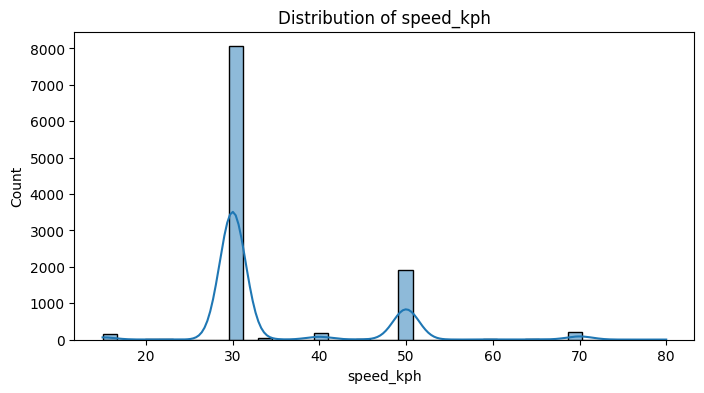

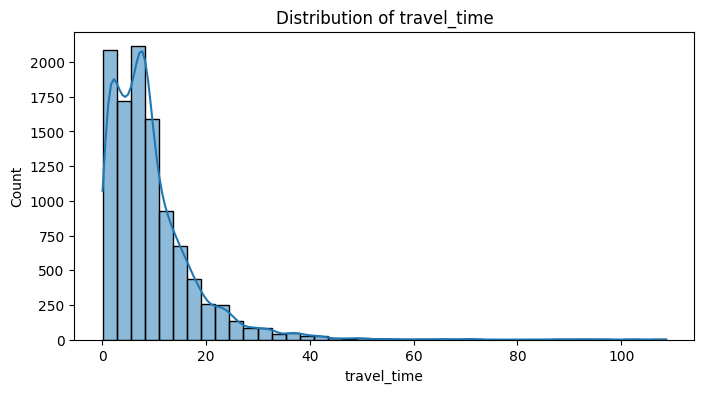

highway
residential                     5899
tertiary                        1968
unclassified                     990
secondary                        900
primary                          303
busway                           246
living_street                    130
primary_link                      55
[unclassified, residential]       31
secondary_link                    17
[primary_link, tertiary]           4
tertiary_link                      4
[living_street, residential]       2
[primary, trunk]                   2
trunk_link                         2
Name: count, dtype: int64
                count  median       mean
highway_norm                            
residential      5899    30.0  30.586236
tertiary         1968    30.0  35.330285
unclassified     1021    30.0  33.351871
secondary         900    50.0  47.833333
primary           305    70.0  62.295082
busway            246    50.0  44.703390
living_street     132    15.0  15.113636
primary_link       59    50.0  52.203390
s

In [5]:
graph=graph.copy()

graph=ox.add_edge_speeds(graph)
graph=ox.add_edge_travel_times(graph)
n2, e2=ox.graph_to_gdfs(graph)

print([c for c in e2.columns if "speed" in c or "time" in c])
print(e2[["length", "speed_kph", "travel_time"]].isna().sum())
print(e2[["speed_kph", "travel_time"]].describe())

field="speed_kph"
plt.figure(figsize=(8,4))
sns.histplot(e2[field].dropna(), bins=40, kde=True)
plt.title(f"Distribution of {field}")
plt.show()

field="travel_time"
plt.figure(figsize=(8,4))
sns.histplot(e2[field].dropna(), bins=40, kde=True)
plt.title(f"Distribution of {field}")
plt.show()

print(e2["highway"].value_counts(dropna=False).head(15))

tmp = e2.copy()
tmp["highway_norm"] = tmp["highway"].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x
)

summary = (
    tmp.dropna(subset=["highway_norm", "speed_kph"])
       .groupby("highway_norm")["speed_kph"]
       .agg(["count", "median", "mean"])
       .sort_values("count", ascending=False)
       .head(15)
)

print(summary)


## Route Baseline EDA

In [12]:
origin=(51.446915422770466, 5.503542626552148)
destination=(51.45128576098493, 5.479564794710434)
G=graph

orig_node = ox.distance.nearest_nodes(G, X=origin[1], Y=origin[0])
dest_node = ox.distance.nearest_nodes(G, X=destination[1], Y=destination[0])
route_len = nx.shortest_path(G, orig_node, dest_node, weight="length")
route_time = nx.shortest_path(G, orig_node, dest_node, weight="travel_time")

print("Same route?", route_len == route_time)
print("Length-route nodes:", len(route_len))
print("Time-route nodes:", len(route_time))



Same route? False
Length-route nodes: 33
Time-route nodes: 29


## Route Comparison table (distance+time)

In [13]:
def route_totals(G, route):
    edges=list(zip(route[:-1], route[1:]))

    total_length_m=0
    total_time_s=0
    for u, v in edges:
        edge_dict=G.get_edge_data(u, v)
        best_key=min(edge_dict, key=lambda k: edge_dict[k].get("travel_time", float("inf")))
        data=edge_dict[best_key]

        total_length_m += data.get("length", 0)
        total_time_s += data.get("travel_time", 0)

    return total_length_m, total_time_s

len_dist, len_time = route_totals(G, route_len)
time_dist, time_time = route_totals(G, route_time)

comparison=pd.DataFrame([
    {"route_type": "shortest_length", "distance_m": len_dist, "travel_time_s": len_time},
    {"route_type": "shortest_time",   "distance_m": time_dist, "travel_time_s": time_time},
])

comparison["distance_km"]=comparison["distance_m"]/1000
comparison["travel_time_min"]=comparison["travel_time_s"]/60

print(comparison[["route_type", "distance_km", "travel_time_min"]])



        route_type  distance_km  travel_time_min
0  shortest_length     3.837664         6.570697
1    shortest_time     4.018154         4.979611


## Visualization of both routes

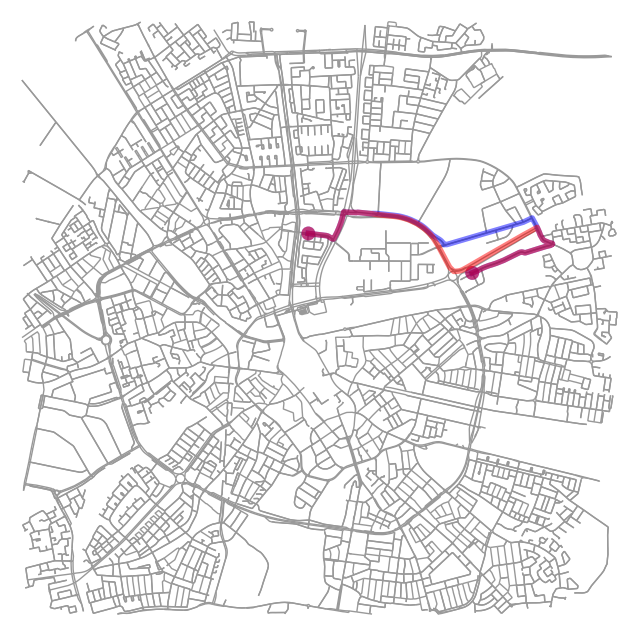

In [14]:
fig, ax=ox.plot_graph_routes(
    G,
    [route_len, route_time],
    route_colors=["blue","red"] ,    #blue=length, red=time
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
)

## Saving graph

In [15]:
from pathlib import Path

out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "eindhoven_drive_processed.graphml"
ox.save_graphml(G, filepath=out_path)

print("Saved:", out_path)


Saved: data\eindhoven_drive_processed.graphml
